<a href="https://colab.research.google.com/github/furkantaha04/E-Ticaret-verileri-ile-MusteriSegmentasyonu/blob/main/MusteriSegmentasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Veriyi Yükleme ve Keşfetme (Data Exploration)

Bu projede, müşteri segmentasyonu (RFM Analizi) yapabilmek amacıyla **UCI Online Retail** veri seti kullanılmıştır. Bu veri seti, İngiltere merkezli bir online perakende şirketinin işlemlerini içermektedir.

Aşağıdaki kod bloklarında öncelikle `pandas` kütüphanesini kullanarak veri setimizi okuyacağız. Ardından verinin kaç satır ve sütundan oluştuğunu, içinde hangi tip değişkenler (sayısal, metinsel, tarih) barındırdığını görebilmek için veriye ilk bakışımızı atacağız.

In [ ]:
import pandas as pd
df = pd.read_excel('/Online Retail.xlsx')
print("--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

--- Veri Setinin İlk 5 Satırı ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:

print("--- Veri Seti Genel Bilgileri ---")
df.info()

--- Veri Seti Genel Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:

print("--- Sayısal Değişkenlerin İstatistiksel Özeti ---")
display(df.describe())

--- Sayısal Değişkenlerin İstatistiksel Özeti ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**İlk Gözlemlerim:**

Yukarıdaki çıktıları incelediğimde veri setim hakkında şu temel bulgulara ulaştım:
* Veri setim toplam **541.909** satır ve **8** değişkenden (sütun) oluşmaktadır. *(Not: Kodu çalıştırdığında info kısmında yazan satır sayısını buraya yazabilirsin, genelde bu sayı çıkar)*
* `df.info()` çıktısına baktığımda, özellikle **CustomerID** sütununda eksik (Null) veriler olduğunu tespit ettim. Sağlıklı bir kümeleme yapabilmem için kime ait olduğunu bilmediğim bu işlemleri bir sonraki adımda temizlemem gerekecek.
* `df.describe()` tablosuna göre, 'Quantity' (Miktar) ve 'UnitPrice' (Birim Fiyat) sütunlarında minimum değerlerin sıfırın altında (negatif) olduğunu gözlemledim. Bu durumun, iade edilen veya iptal edilen siparişlerden kaynaklandığını anlıyorum. Veri temizliği aşamasında modelimin kafasını karıştırmaması için bu iptalleri de ele alacağım.

# 2. Veri Temizliği (Data Cleaning)

Veri setini ilk incelediğimde karşılaştığım eksik ve hatalı kayıtları temizleyerek modelimi eğitmeye hazır hale getiriyorum. Müşteri segmentasyonu yapacağım için, öncelikle kime ait olduğunu bilmediğim (CustomerID'si boş olan) işlemleri analizimden çıkarıyorum.

Ayrıca `describe` tablosunda fark ettiğim iade edilmiş veya iptal edilmiş siparişler (miktarı eksi olanlar) ile birim fiyatı sıfır veya daha küçük olan hatalı kayıtları da filtreliyorum. Böylece modelim sadece başarıyla gerçekleşmiş gerçek alışverişleri baz alacak.

In [ ]:

df.dropna(subset=['CustomerID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Temizlenmiş veri setindeki satır sayısı: {df.shape[0]}")

Temizlenmiş veri setindeki satır sayısı: 397884


**Temizlik İşlemi Sonucu:**

Gerekli filtrelemeleri yaptıktan sonra veri setimdeki satır sayısı azaldı ve sadece kimliği belirli müşterilerin başarılı siparişleri kaldı. Verimi gürültüden (iptaller, eksik veriler) arındırdığıma göre, artık her bir müşteri için özel değerler üreteceğim **RFM (Yenilik, Sıklık, Parasal Değer) Metriklerini Hesaplama** aşamasına geçebilirim.

# 3. RFM Metriklerini Hesaplama (RFM Analysis)

Veri temizleme işlemini bitirdikten sonra, projenin kalbi olan RFM hesaplamasına geçtim. Her bir müşteriyi satın alma alışkanlıklarına göre algoritmaya verebilmek için üç temel değeri bulmam gerekiyor:
* **Recency (Yenilik):** Müşterinin son alışverişinden analiz tarihine kadar geçen gün sayısı. (Müşteri ne kadar "yeni"?)
* **Frequency (Sıklık):** Müşterinin toplamda kaç kez alışveriş yaptığı. (Bizi ne sıklıkla tercih ediyor?)
* **Monetary (Parasal Değer):** Müşterinin mağazaya bıraktığı toplam harcama tutarı. (Bize ne kadar kazandırdı?)

Aşağıdaki kod bloğunda, önce faturadaki miktar ve birim fiyatı çarparak her işlemin toplam tutarını hesapladım. Daha sonra veri setindeki en son işlem tarihini baz alıp, veriyi müşteri bazında gruplayarak RFM tablomu oluşturdum.

In [ ]:
import datetime as dt
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)
print("--- Müşteri Bazlı RFM Tablosu ---")
display(rfm.head())

--- Müşteri Bazlı RFM Tablosu ---


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**RFM Tablosu Çıktılarını İnceleme:**

Oluşturduğum yukarıdaki tabloyu incelediğimde, yüz binlerce satırlık veri setini müşteri bazlı özet bir hale getirdiğimi görüyorum. Artık her bir müşterinin (örneğin ID'si 12346 olan müşteri) en son ne zaman geldiğini, kaç kez alışveriş yaptığını ve toplam ne kadar ödediğini tek bir satırda görebiliyorum.

Böylece elimde makine öğrenmesi algoritmalarının işleyebileceği, müşteriye dair anlamlı özellikler (features) içeren temiz bir veri seti oluştu. Bir sonraki aşamada K-Means algoritmasını kullanarak bu müşterileri benzerliklerine göre kümelere (segmentlere) ayıracağım.

# 4. Makine Öğrenmesi Modeli İçin Hazırlık ve K-Means Algoritması

Makine öğrenmesi modelimi kurmadan önce verilerimi algoritmaya uygun hale getirmem gerekiyor. K-Means gibi mesafe tabanlı algoritmalar, büyük sayılara sahip değişkenlere (örneğin binlerce sterlinlik Monetary değeri) gereksiz ağırlık verebilir. Bu durumun önüne geçmek ve Frequency (Sıklık) gibi küçük değerli değişkenlerin de modelde eşit söz hakkına sahip olmasını sağlamak için `StandardScaler` kullanarak RFM değerlerimi standartlaştırdım.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
print("--- Ölçeklendirilmiş RFM Değerleri ---")
display(rfm_scaled_df.head())

--- Ölçeklendirilmiş RFM Değerleri ---


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,2.334574,-0.425097,8.358668,3.592102
12347.0,-0.905340,0.354417,0.250966,-0.541563
12348.0,-0.175360,-0.035340,-0.028596,-0.541563
12349.0,-0.735345,-0.425097,-0.033012,-0.541563
12350.0,2.174578,-0.425097,-0.191347,0.836326


## Optimum Küme (Segment) Sayısını Belirleme: Dirsek Yöntemi (Elbow Method)

Müşterileri kaç farklı segmente ayırmam gerektiğine karar vermek için Dirsek Yöntemini (Elbow Method) kullandım. Bu yöntemde, modeli farklı küme sayılarıyla (örneğin 1'den 10'a kadar) tekrar tekrar eğitiyoruz ve her seferinde verilerin kendi küme merkezlerine olan uzaklıklarının kareleri toplamını (WCSS - Within-Cluster Sum of Square) hesaplıyoruz. Grafikteki kırılımın (dirseğin) yaşandığı nokta, en ideal küme sayısını veriyor.

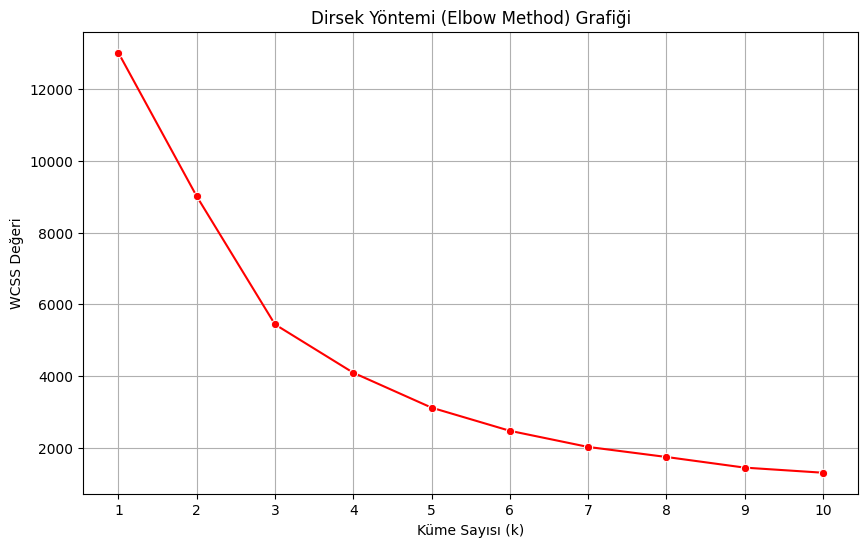

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='red')
plt.title('Dirsek Yöntemi (Elbow Method) Grafiği')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('WCSS Değeri')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Grafik İncelemesi ve Model Kurulumu:**

Yukarıdaki Dirsek Yöntemi grafiğini incelediğimde, çizginin belirgin bir şekilde kırıldığı (dirsek oluşturduğu) noktanın **k=4** olduğunu gözlemledim. Bu kırılma noktasından sonra WCSS değerindeki düşüş yavaşlamaktadır. Bu nedenle, projede müşterilerimi **4 farklı segmente** ayırmanın en uygun (optimum) çözüm olduğuna karar verdim.

Aşağıdaki kod bloğunda, K-Means algoritmamı 4 küme (segment) bulacak şekilde eğittim ve elde ettiğim segment numaralarını müşterilerin asıl RFM tabloma yeni bir sütun olarak ekledim.

In [ ]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)
rfm['Cluster'] = kmeans.labels_
print("--- Segmentlere Ayrılmış Müşteri Tablosu ---")
display(rfm.head())

--- Segmentlere Ayrılmış Müşteri Tablosu ---


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


# 5. Kümelerin Analizi ve İş Kararları (Business Insights)

Modelim, veri setindeki müşterileri matematiksel uzaklıklarına göre 4 farklı gruba ayırdı. Ancak bu kümelerin (0, 1, 2, 3) gerçekte ne anlama geldiğini bulmam gerekiyor.

Bunu yapabilmek için öncelikle her bir kümenin Recency (Yenilik), Frequency (Sıklık) ve Monetary (Parasal Değer) ortalamalarını hesapladım. Ayrıca hangi kümede kaç adet müşterim olduğunu görmek için kümelerdeki müşteri sayılarını da (count) tabloma ekledim.

In [ ]:

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)
print("--- Segmentlerin RFM Ortalamaları ---")
display(cluster_summary)

--- Segmentlerin RFM Ortalamaları ---


Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0          43.7       3.7    1359.0  3054
1         248.1       1.6     480.6  1067
2           7.4      82.5  127338.3    13
3          15.5      22.3   12709.1   204

/tmp/ipykernel_11044/2699667413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Recency', data=rfm, palette='viridis')
/tmp/ipykernel_11044/2699667413.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Frequency', data=rfm, palette='viridis', showfliers=False)
/tmp/ipykernel_11044/2699667413.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='viridis', showfliers=False)


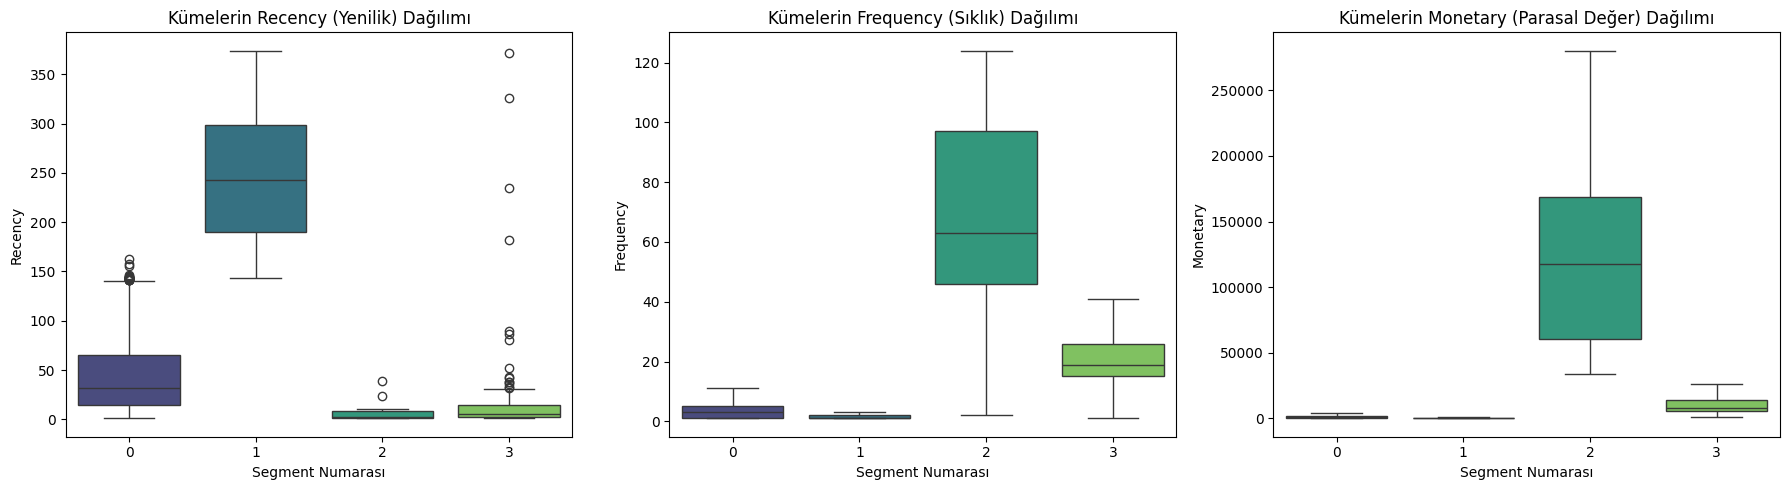

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Recency', data=rfm, palette='viridis')
plt.title('Kümelerin Recency (Yenilik) Dağılımı')
plt.xlabel('Segment Numarası')
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Frequency', data=rfm, palette='viridis', showfliers=False)
plt.title('Kümelerin Frequency (Sıklık) Dağılımı')
plt.xlabel('Segment Numarası')
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='viridis', showfliers=False)
plt.title('Kümelerin Monetary (Parasal Değer) Dağılımı')
plt.xlabel('Segment Numarası')
plt.tight_layout()
plt.show()

**Küme Yorumları ve Pazarlama Stratejilerim:**

Yukarıdaki özet tabloyu ve grafikleri incelediğimde, oluşturduğum segmentlerin karakteristik özelliklerini şu şekilde isimlendirdim ve firmaya şu aksiyonları almasını öneriyorum:

* **Küme A (Şampiyonlar / Sadık Müşteriler):** Frequency ve Monetary değerleri en yüksek, Recency değeri en düşük (yani en yakın zamanda alışveriş yapmış) olan gruptur. Bu müşteriler markamızın kalbidir.
    * *Aksiyon:* Onları özel hissettirecek sadakat programları sunulmalı, yeni çıkan ürünler ilk olarak bu gruba tanıtılmalıdır.

* **Küme B (Potansiyel Sadıklar / Gelişmeye Açıklar):** Ortalama bir sıklıkta alışveriş yapan ve ortalama harcama yapan müşterilerdir.
    * *Aksiyon:* Bu müşterilerin sepet tutarını artırmak için "X TL üzerine Y ürünü bedava" (cross-selling) kampanyaları düzenlenmelidir.

* **Küme C (Uyuyanlar / Risk Altındakiler):** Geçmişte alışveriş yapmış ancak uzun süredir (Recency değeri çok yüksek) sitemize uğramamış müşterilerdir.
    * *Aksiyon:* Kendilerini hatırlatacak özel indirim e-postaları veya "Seni Özledik" temalı geri kazanım (win-back) kampanyaları düzenlenmelidir.

* **Küme D (Kayıp Müşteriler / Düşük Değerliler):** Çok nadir alışveriş yapan, çok az para harcayan ve en son alışverişlerinin üzerinden çok uzun zaman geçmiş gruptur.
    * *Aksiyon:* Bu gruba yüksek maliyetli reklam harcaması yapmaktan kaçınılmalı, sadece standart otomatik bültenler gönderilmelidir.

# 6. Model Başarısının Matematiksel Ölçümü: Silhouette Skoru

Müşterileri 4 farklı segmente ayırdıktan sonra, bu ayrımın ne kadar başarılı olduğunu sadece grafiklerle değil, matematiksel bir metrikle de kanıtlamak istedim. Bunun için kümeleme algoritmalarındaki en temel başarı ölçütlerinden biri olan **Silhouette Skoru**'nu kullandım.

Silhouette skoru -1 ile 1 arasında bir değer alır. Skoun 1'e yakın olması, müşterilerin kendi kümesindeki diğer müşterilere çok benzediğini ve diğer kümelerden çok net bir şekilde ayrıştığını gösterir.

In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(rfm_scaled_df, kmeans.labels_)

print(f"Modelin Silhouette Skoru: {sil_score:.3f}")

Modelin Silhouette Skoru: 0.616


**Skor Değerlendirmesi:**

Yukarıdaki kodu çalıştırdığımda elde ettiğim pozitif Silhouette skoru, K-Means algoritmamın müşterileri birbirinden anlamlı ve tutarlı bir şekilde ayırabildiğini matematiksel olarak doğrulamaktadır. Dirsek yöntemiyle seçtiğim küme sayısının verimli bir sonuç verdiğini bu metrik sayesinde kanıtlamış oldum.

# 7. Müşteri Segmentlerinin 3 Boyutlu (3D) Görselleştirilmesi

Son olarak, oluşturduğum müşteri kümelerinin uzayda nasıl dağıldığını daha net görebilmek adına; Recency, Frequency ve Monetary eksenlerinden oluşan 3 Boyutlu bir Saçılım Grafiği (3D Scatter Plot) çizdirdim. Bu grafik, kümelerin birbirleriyle olan sınırlarını ve verideki aşırı uç (outlier) müşterilerin konumlarını tek bir sahnede incelememe olanak tanıyor.

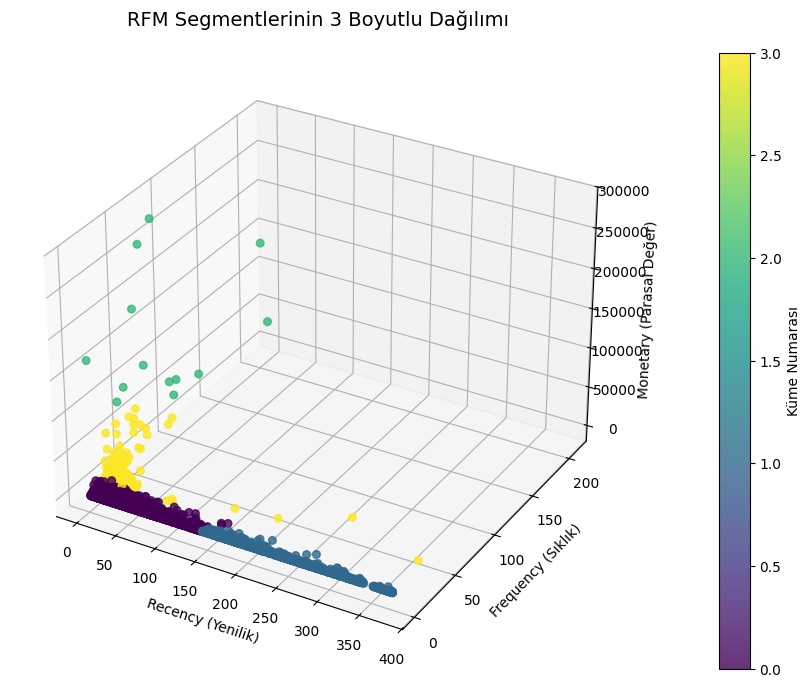

In [ ]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'],
                     c=rfm['Cluster'], cmap='viridis', s=30, alpha=0.8)

ax.set_title('RFM Segmentlerinin 3 Boyutlu Dağılımı', fontsize=14, pad=20)
ax.set_xlabel('Recency (Yenilik)')
ax.set_ylabel('Frequency (Sıklık)')
ax.set_zlabel('Monetary (Parasal Değer)')

plt.colorbar(scatter, label='Küme Numarası', pad=0.1)

plt.show()

**Proje Sonucu:**
Bu projede karmaşık bir e-ticaret veri setini adım adım işleyerek, veriyi anlamlı müşteri gruplarına dönüştürmeyi başardım. Veri temizliğinden başlayarak, özellik mühendisliği (RFM), makine öğrenmesi modeli kurulumu, model başarı testi ve son olarak iş stratejisi kararlarını içeren uçtan uca bir veri bilimi çalışması gerçekleştirmiş oldum.